# Business Sales Analysis (Descriptive, TimeSeries, & Exploratory Analysis)

This report details a deepdive into Digistore Sales data with the goal of exploring it's overall health, understanding the distibution of features, and identifying patterns that exist within the data.

### Data Health:
The data is fairly complete with no missing rows, but contains some inconsistencies on in formatting within features. The data granularity is at Order item level.

### Critical Findings:
   - Baseline sales has grown by approxiamtely 20% annually over the last 3 years, after removing monthly noise and seasonal effects.
   - Sales has a seasonality element, peaking in September and November through December, then slowing down in January and dipping in February.
   - Sales increased over the years from \\$483966.13 and \\$470532.51 in 2014 and 2015 respectively, to \\$609205.60 and \\$733215.26 in 2016 and 2017 respectively. The increase is consistent across Regions, Segments, and Categories which indicates growth across board within the business. The West Region had the highest Sales increase in 2017.
  - While overall Sales has increased, overall Profit has increased at a much slower rate with some regions and categories even recording overall losses. Central region and Furniture Categories are most affected, with Central region recording an overall loss in 2014, and Furniture category recording overall losses in 2016 and 2017.
  - Up to 18% of Sales have resulted in losses for the business.
  - Discounts indicate responsibitity for the disparity in Sales growth vs Profit growth. Discounts in this data have limited effect on Sales numbers, while having a larger effect on Profits.
  - The top 5% of sales are responsible for 52.89% of total profits.
  - Technology products account for almost half(45.7%) of the top 5% of Sales.

### Recommendations:
- Capitalize on the seasonality within sales to drive revenue and profits during peak demand periods. Consider additional campaigns and other sales drivers for these periods.
- Reevaluate the discount strategy to ensure it drives Sales positively and maintains positive Profit margins. 
- Though their sales numbers are consistent, Profits in the Central customer region and Furniture product category have been remarkably low when compared to other groups. Consider revaluating pricing, cost reduction, or seperate and more specific discount strategy for these groups.
- Technology products account for a large number of high value sales. Driving more of these high value sales will have a high impact overall on revenue and profits.

## Data Overview and Health Audit (Data Cleaning)
Before looking for business trends, we audited the data for cleanliness and formatting errors.
- Data Type Corrections: \
      The Order Date and Ship Date columns were corrected from String to Date. Other columns had accurate data types.

- Duplicates: \
      1 identical duplicate row was present, and was removed to keep our observations accurate.

- Missing Values (Nulls): \
      No missing values

- Data Granularity: \
      Data is not aggregated, and is consistent at order, item level.

- Metadata: \
Row ID => Unique ID for each row.\
Order ID => Unique Order ID for each Customer.\
Order Date => Order Date of the product.\
Ship Date => Shipping Date of the Product.\
Ship Mode=> Shipping Mode specified by the Customer.\
Customer ID => Unique ID to identify each Customer.\
Customer Name => Name of the Customer.\
Segment => The segment where the Customer belongs.\
Country => Country of residence of the Customer.\
City => City of residence of of the Customer.\
State => State of residence of the Customer.\
Postal Code => Postal Code of every Customer.\
Region => Region where the Customer belongs.\
Product ID => Unique ID of the Product.\
Category => Category of the product ordered.\
Sub-Category => Sub-Category of the product ordered.\
Product Name => Name of the Product.\
Sales => Sales of the Product.\
Quantity => Quantity of the Product.\
Discount => Discount provided.\
Profit => Profit/Loss incurred.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import scipy.stats as stats

# Detect the encoding automatically using the chardet library:
import chardet
with open("./data/digistore.csv", "rb") as f:
    result = chardet.detect(f.read(100000))

# Read file
df = pd.read_csv('./data/digistore.csv', encoding=result['encoding']).iloc[:,1:]

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # pandas remove max col width
display(df.head()) #display(df.tail())
# display(df.info()) #Feature Information

# Data Cleaning
df[['Order Date', 'Ship Date']] = df[['Order Date', 'Ship Date']].apply(pd.to_datetime, format='%m/%d/%Y') # Update data types #date columns to datetime
df = df.drop_duplicates() #Drop duplicates

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400,3,0.00,219.5820
2,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200,2,0.00,6.8714
3,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


##

## Key Distributions and Patterns (Summary Statistics)
This section highlights the observes shape, spread, and details of the fetautes within the data.
- #### Feature Distribution (Shape of the features):
  - #### Sales:
      Sales is centered at \\$54.48, with the middle 50% spread from \\$17.28 to \\$209.94. The values are spread out with 75% being under \\$209.94, 95% being under \\$956.98, and 99% being below \\$2481.69. Sales skew is measured at 12.97, which is a heavy right skew that also accounts for the high difference between the Mean -at \\$229.85, and the Median -at \\$54.49. The heavy right skew also results in continuous outliers; with some outliers - like the max sales value at $22638.48 - being more extreme than others.These extreme values are closer analyzed in the outliers section of this report
  - #### Profit:
       Profit is centered at \\$8.67 with the middle 50% spread from \\$1.73 to \\$29.36. 18.71% of Profits are negative (losses). While it's distribution appears normal, the skew measures at 7.56 resulting from extreme outlies on both sides of the distribution. The largest on both sides being the min value at \\$-6599.97, and the max value at \\$8399.97. These extreme values are further analyzed in the outliers section of this report.
  - #### Region:
      The data is split into customers in East, West, South and Central Regions with West being the region with the highest frequency(32.1% of the data). East has 28.5%, 23.2%, and South has 16.2%.
  - #### Segment:
      The data is also split into customers in Consumer, Corporate, and Home Office Segments Consumer segment covering 51.9% of the data. Corporate has 30.2% of the data, while Home Office covers 17.8%.
  - #### Category:
      Product categories are Office Supplies, Furniture, and Technology with Office Supplies covering 60.3% of the data. Furniture has 21.25, and Technology has 18.5%.

In [2]:
df.describe()

,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9993,9993,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,2016-04-30 01:53:33.089162,2016-05-04 00:53:19.039327,55191.576403,229.852846,3.789753,0.156188,28.660971
min,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.731000
50%,2016-06-26 00:00:00,2016-06-29 00:00:00,56560.000000,54.480000,3.000000,0.200000,8.671000
75%,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,NaN,NaN,32065.074478,623.276074,2.225149,0.206457,234.271476


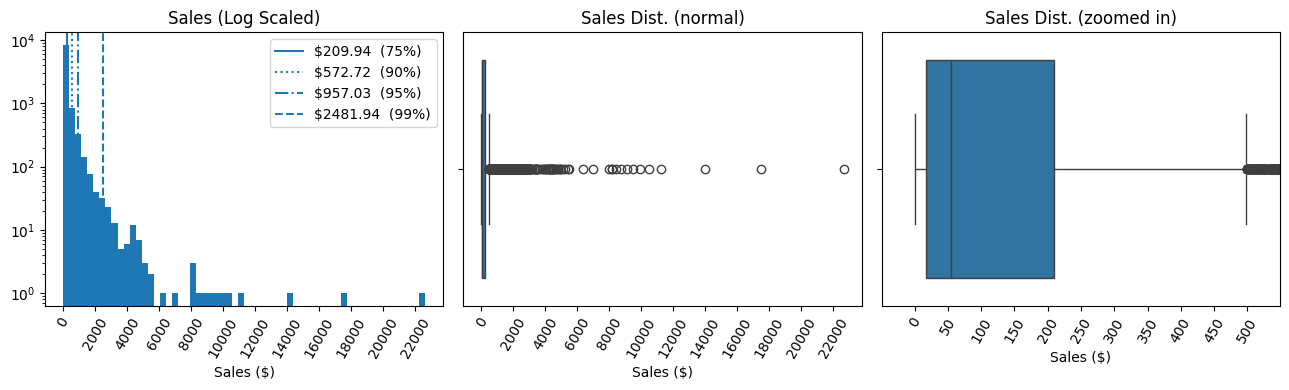

Sales Skew: 12.970194292905331



In [3]:
# Sales
sales_q1, sales_q2, sales_q3, sales_q90, sales_q95, sales_q99 = df['Sales'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
sales_iqr = sales_q3-sales_q1
sales_lower = sales_q1 - (1.5 * sales_iqr)
sales_upper = sales_q3 + (1.5 * sales_iqr)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4))
for axs in [ax1, ax2, ax3]:
    axs.set_xlabel('Sales ($)')
    axs.tick_params(axis='x', labelrotation=60)

ax1.hist(df['Sales'], bins=60)
ax1.set(title='Sales (Log Scaled)', yscale='log')
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2000))
lines = {'75':[sales_q3, 'solid'], '90':[sales_q90, 'dotted'], '95':[sales_q95, 'dashdot'], '99':[sales_q99, 'dashed']}
for key, value in lines.items():
    ax1.axvline(value[0], linestyle=value[1], label=f'${value[0]:.2f}  ({key}%)')
ax1.legend()

sns.boxplot(x='Sales', data=df, ax=ax2)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(2000))
ax2.set(title='Sales Dist. (normal)')

sns.boxplot(x='Sales', data=df, ax=ax3)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax3.set(xlim=[df['Sales'].min() - 50, sales_upper+50], title='Sales Dist. (zoomed in)')

plt.tight_layout()
plt.show()

print(f'Sales Skew: {stats.skew(df['Sales'])}\n')

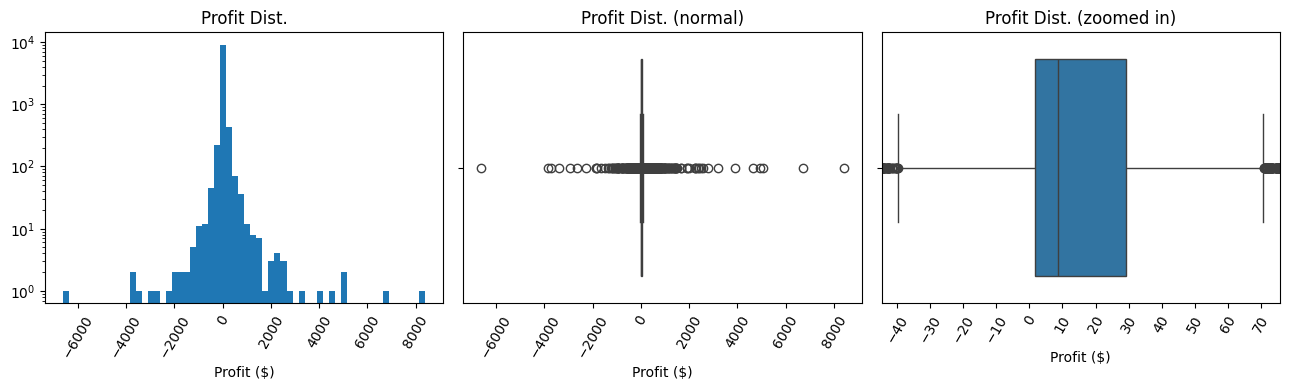

Profit Skew: 7.559900998851114

Negative Profits (Loss) % : 0.18713099169418593


In [4]:
# Profit
profit_q1, profit_q2, profit_q3, profit_q90, profit_q95, profit_q99 = df['Profit'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
profit_iqr = profit_q3 - profit_q1

# Boundaries
profit_lower = profit_q1 - (1.5 * profit_iqr)
profit_upper = profit_q3 + (1.5 * profit_iqr)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4))
for axs in [ax1, ax2, ax3]:
    axs.set_xlabel('Profit ($)')
    axs.tick_params(axis='x', labelrotation=60)

ax1.hist(df['Profit'], bins=60)
ax1.set(title='Profit Dist.', yscale='log')

sns.boxplot(x='Profit', data=df, ax=ax2)
#ax2.xaxis.set_major_locator(ticker.MultipleLocator(2000))
ax2.set_title('Profit Dist. (normal)')

sns.boxplot(x='Profit', data=df, ax=ax3)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax3.set(xlim=[profit_lower-5, profit_upper+5], title='Profit Dist. (zoomed in)')

plt.tight_layout()
plt.show()
print(f'Profit Skew: {stats.skew(df['Profit'])}\n')
print(f'Negative Profits (Loss) % : {(df[df['Profit'] < 0].shape[0]) /df.shape[0]}')

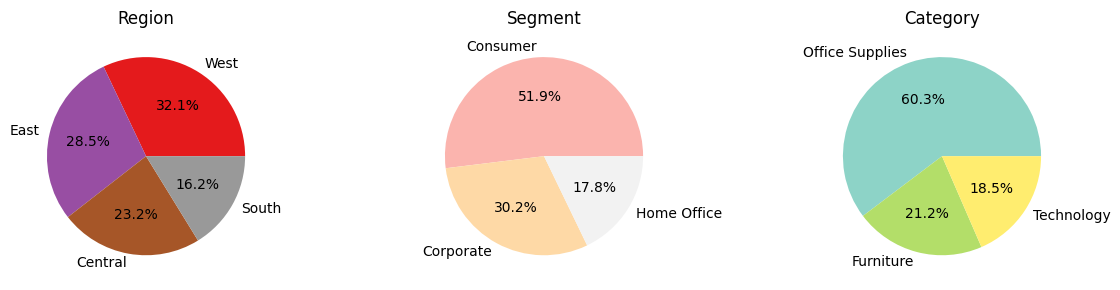

In [5]:
# Categorical variables: Region, Segment, and Category
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))

df['Region'].value_counts().plot.pie(autopct='%.1f%%', cmap='Set1', ax=ax1)
ax1.set_title('Region')

df['Segment'].value_counts().plot.pie(autopct='%.1f%%', cmap='Pastel1', ax=ax2) #turbo jet
ax2.set_title('Segment')

df['Category'].value_counts().plot.pie(autopct='%.1f%%', cmap='Set3', ax=ax3)
ax3.set_title('Category')

plt.tight_layout()
plt.show()

##

## Key Relationships (TimeSeries, Bivariate and Multivariate Analysis)
#### Time Series:
- Sales has an upward trend, increasing over the years. Over the last 3 years, removing the monthly noise, baseline sales has been improving by approxiamtely 20% annually. The business is growing.
- Sales has a seasonality element, peaking in September and November through December, then slowing down in January and dipping in February.
- Sales increase is across board. Being faily consistent across Regions, Segments, and Categories.
- West Region has the highest Sales increase in 2017.
- Yearly sales volume increased from under \\$500,000 in 2014 and 2015, to over \\$600,000 in 2016, and over \\$700,000 in 2017.

#### Sales, Profit, Region, Segment, Category:
- Discount is not associated with Sales(corr=-0.15), but has a calculated negative association with Profits(corr=-0.55).
- There is an observed positive association between Sales and Profit(chi2=0.55).
- Comparing Sales across Region, Segment, and Category, there is no notable mean or median difference between the Regions and Segments. For Category however, at first glance there seems to be a difference with Office Supplies, but on closer look Office Supplies' low median is offset by the sales count, which puts its Sales volume within the same overlap range as Furniture and Technology.

#### Region, Segment, Category:
- There is no observed association between Region and Category, and also none between Segment and Category.

### TimeSeries

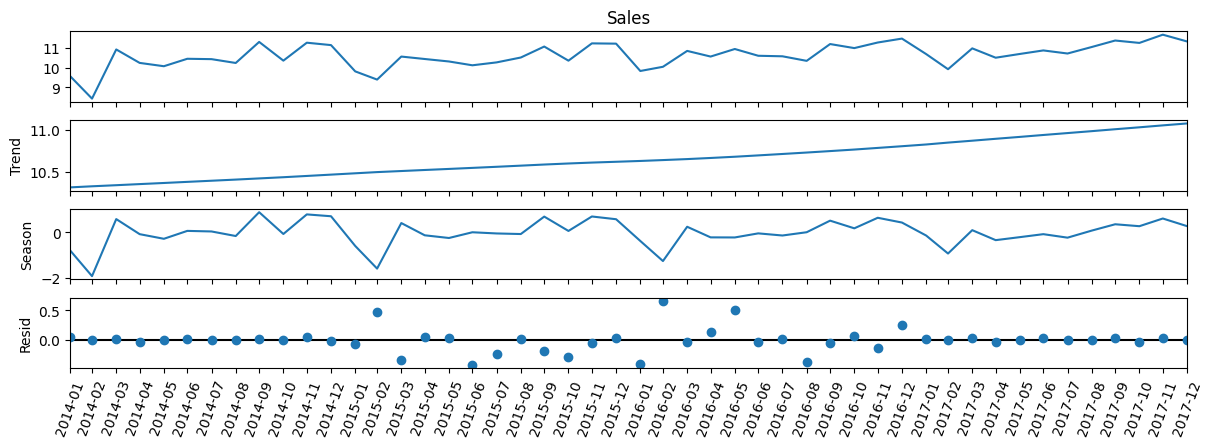

,Actual Sales,Trend Component,Seasonal Component,Residual Component
Order Date,,,,
2014-01-31,14236.895,30219.397958,0.453872,1.037997
2014-02-28,4519.892,30609.879499,0.147618,1.000294
2014-03-31,55691.009,31009.046094,1.785572,1.005818
2014-04-30,28013.973,31416.574800,0.924241,0.964785
2014-05-31,23648.287,31832.196454,0.754853,0.984171


,Trend_Total,Growth (%)
Order Date,,
2014,390573.562319,NaN
2015,460045.642016,17.787195
2016,537084.448154,16.745905
2017,683714.617202,27.301138


Average Annual Growth: 20.61 
Compund Annual Growth: 20.80


,Seasonal_Multiplier,Seasonal_Lift (%)
Order Date,,
1,0.640571,-35.942893
2,0.258747,-74.125293
3,1.416144,41.614362
4,0.829613,-17.038718
5,0.787067,-21.293310
6,0.987814,-1.218600
7,0.914479,-8.552053
8,0.966712,-3.328783
9,1.873746,87.374556


In [6]:
#TimeSeries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
import numpy as np

monthly_sales_series = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
monthly_sales_series.index.freq = 'ME'

# stl
stl_smodel = STL(np.log(monthly_sales_series), period=12, robust=True).fit()
fig = stl_smodel.plot()
fig.set_size_inches(13, 4)
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(mdates.date2num(monthly_sales_series.index)))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=70)
plt.show()

# actual values, trend values, seasonal values, and residual values for reference
timeseries_sdf = pd.DataFrame({
    'Actual Sales': monthly_sales_series,
    'Trend Component': np.exp(stl_smodel.trend),
    'Seasonal Component': np.exp(stl_smodel.seasonal),
    'Residual Component': np.exp(stl_smodel.resid)
})
display(timeseries_sdf.head(5))

# annual average growth
growth_profile_sdf = pd.DataFrame({
    'Trend_Total': timeseries_sdf['Trend Component'].groupby(timeseries_sdf.index.year).sum()
    })
growth_profile_sdf['Growth (%)'] = growth_profile_sdf.pct_change() * 100
average_growth = growth_profile_sdf['Growth (%)'].sum() / (len(growth_profile_sdf) - 1)

# annual compound growth
trend_start = timeseries_sdf['Trend Component'].iloc[0]
trend_end = timeseries_sdf['Trend Component'].iloc[-1]
num_years = len(timeseries_sdf) / 12
cagr = (((trend_end / trend_start) ** (1/num_years)) - 1) * 100

display(growth_profile_sdf)
print(f'Average Annual Growth: {average_growth:.2f}', f'\nCompund Annual Growth: {cagr:.2f}')

# seasonal profile for sales
seasonal_profile_sdf = pd.DataFrame({
    'Seasonal_Multiplier': timeseries_sdf['Seasonal Component'].groupby(timeseries_sdf.index.month).mean()
    })
seasonal_profile_sdf['Seasonal_Lift (%)'] = (seasonal_profile_sdf['Seasonal_Multiplier'] - 1) * 100
display(seasonal_profile_sdf)

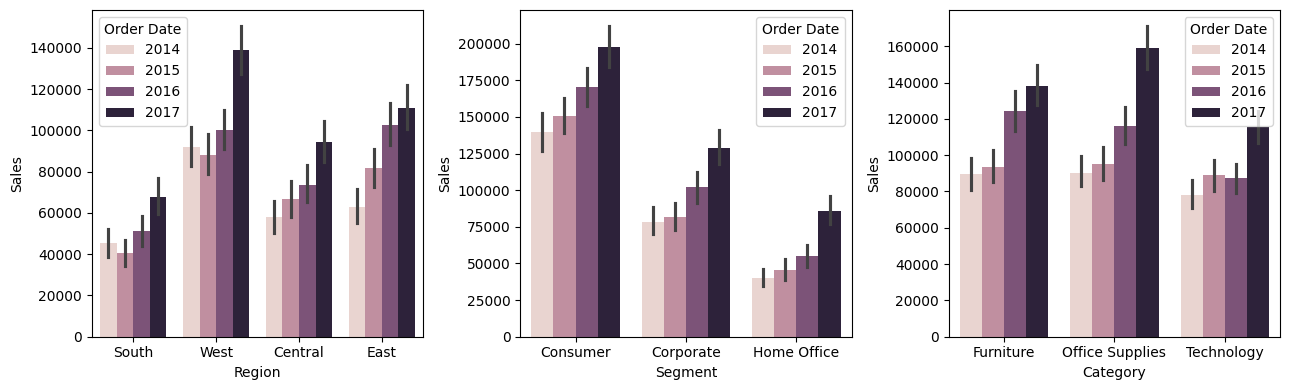

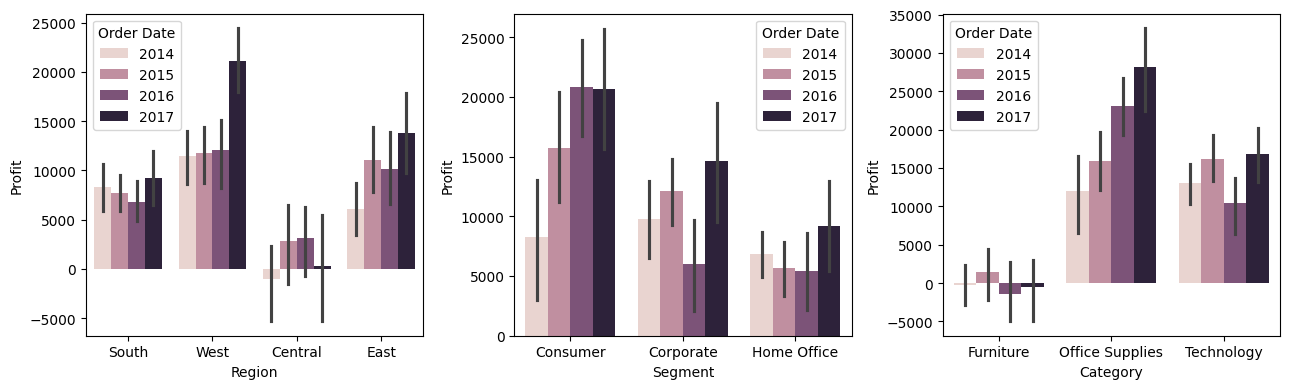

In [7]:
# Sales and profit across years
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4), layout='tight')
sns.barplot(y='Sales', x='Region', hue=df['Order Date'].dt.year, estimator='sum', data=df[df['Sales'] <= sales_q95], ax=ax1)
sns.barplot(y='Sales', x='Segment', hue=df['Order Date'].dt.year, estimator='sum', data=df[df['Sales'] <= sales_q95], ax=ax2)
sns.barplot(y='Sales', x='Category', hue=df['Order Date'].dt.year, estimator='sum', data=df[df['Sales'] <= sales_q95], ax=ax3)
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4), layout='tight')
sns.barplot(y='Profit', x='Region', hue=df['Order Date'].dt.year, estimator='sum', data=df[df['Sales'] <= sales_q95], ax=ax1)
sns.barplot(y='Profit', x='Segment', hue=df['Order Date'].dt.year, estimator='sum', data=df[df['Sales'] <= sales_q95], ax=ax2)
sns.barplot(y='Profit', x='Category', hue=df['Order Date'].dt.year, estimator='sum', data=df[df['Sales'] <= sales_q95], ax=ax3)
plt.show()

In [8]:
print('Sales Over The years')
print(df.groupby(df['Order Date'].dt.year)['Sales'].sum())
print(df['Sales'].sum())

Sales Over The years
Order Date
2014    483966.1261
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64
2296919.4883000003


### Sales

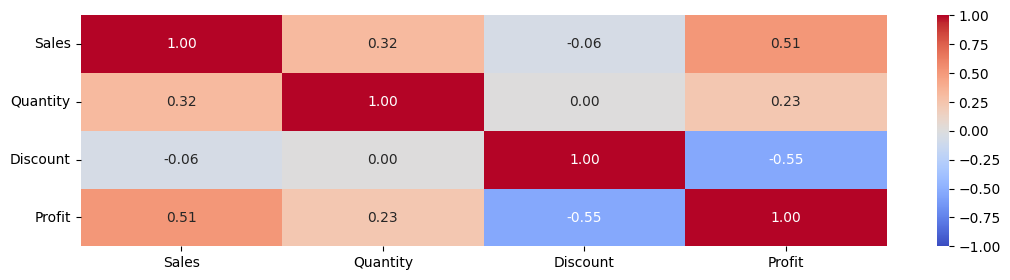

<Figure size 1300x500 with 0 Axes>

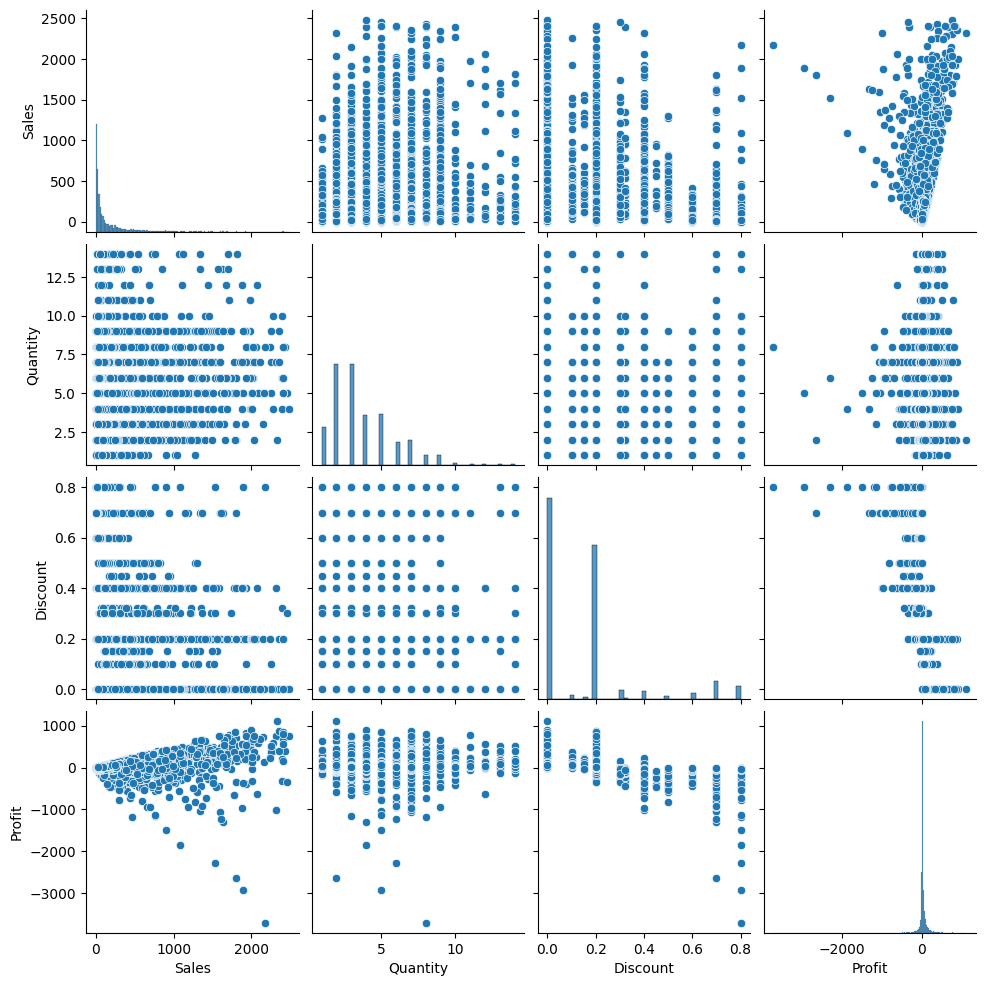

In [9]:
corr_df = df[df['Sales'] <= sales_q99].drop(columns=['Postal Code'])

# Correlation using spearman to account for skewness
corr_matrix = corr_df.corr(method='spearman', numeric_only=True)

plt.figure(figsize=(13, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.show()

plt.figure(figsize=(13, 5))
sns.pairplot(corr_df)
plt.show()

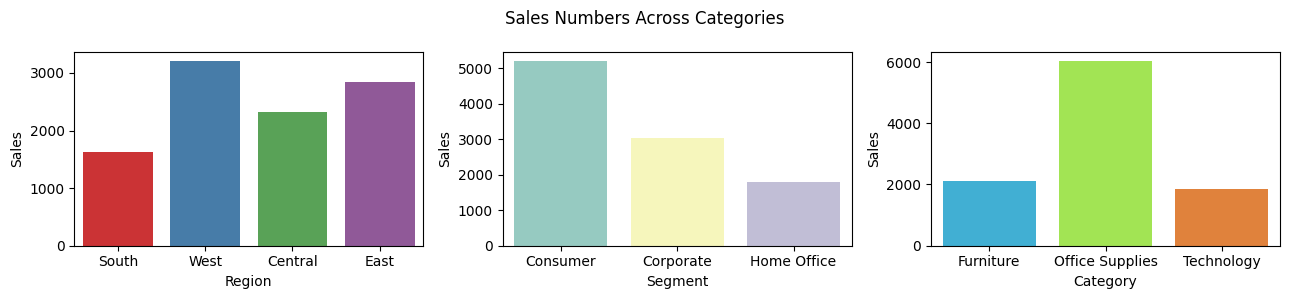

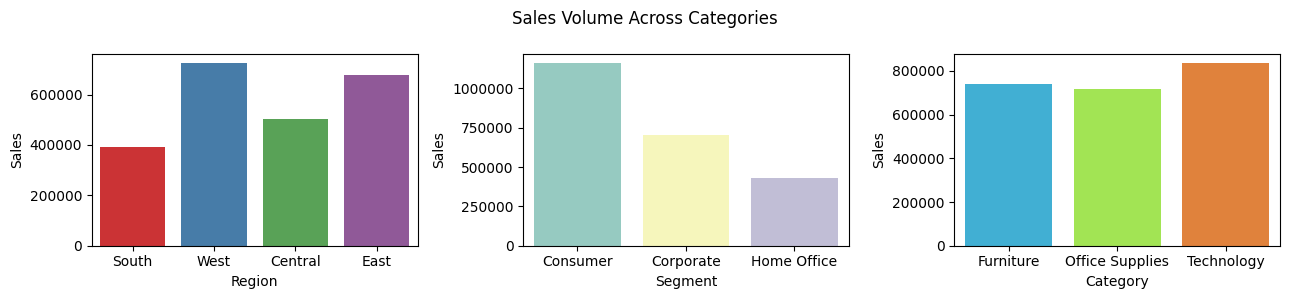

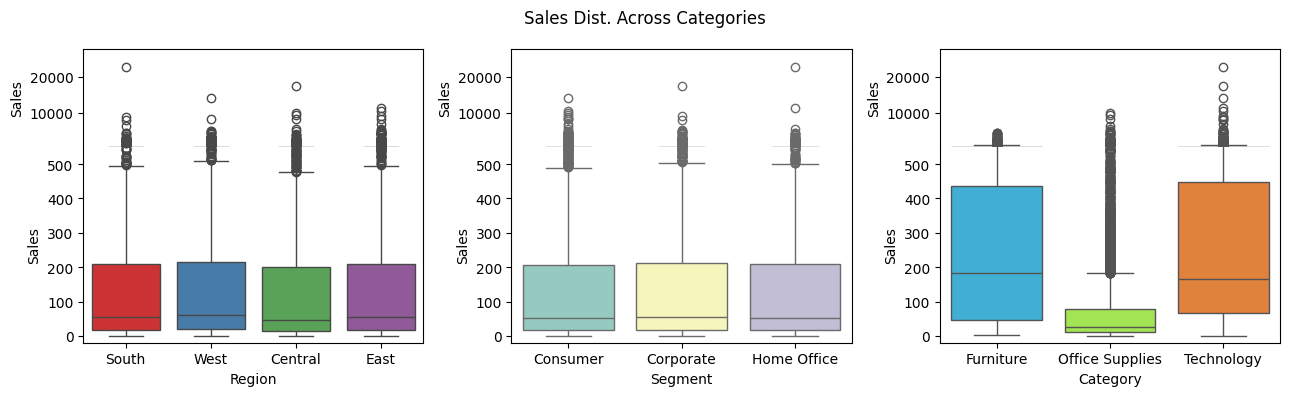

In [10]:
fig, axtop = plt.subplots(1, 3, figsize=(13, 3), layout='tight')
sns.barplot(x='Region', y='Sales', data=df, estimator='count_nonzero', ax=axtop[0], hue='Region', palette='Set1')
sns.barplot(x='Segment', y='Sales', data=df, estimator='count_nonzero', ax=axtop[1], hue='Segment', palette='Set3')
sns.barplot(x='Category', y='Sales', data=df, estimator='count_nonzero', ax=axtop[2], hue='Category', palette='turbo')
plt.suptitle('Sales Numbers Across Categories')
plt.show()

fig, axmid = plt.subplots(1, 3, figsize=(13, 3), layout='tight')
sns.barplot(x='Region', y='Sales', data=df, estimator='sum', ax=axmid[0], errorbar=None, hue='Region', palette='Set1')
sns.barplot(x='Segment', y='Sales', data=df, estimator='sum', ax=axmid[1], errorbar=None, hue='Segment', palette='Set3')
sns.barplot(x='Category', y='Sales', data=df, estimator='sum', ax=axmid[2], errorbar=None, hue='Category', palette='turbo')
axmid[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))
fig.suptitle('Sales Volume Across Categories')
plt.show()

fig, axbottom = plt.subplots(2, 3, sharex='col', gridspec_kw={'height_ratios':[2, 4], 'hspace':0}, figsize=(13, 4), layout='tight')
for plot in axbottom[0]:
    plot.spines['bottom'].set_visible(False)
    plot.set_ylim(550, (df['Sales'].max()+5000))
sns.boxplot(x='Region', y='Sales', data=df, ax=axbottom[0, 0], hue='Region', palette='Set1')
sns.boxplot(x='Segment', y='Sales', data=df, ax=axbottom[0, 1], hue='Segment', palette='Set3')
sns.boxplot(x='Category', y='Sales', data=df, ax=axbottom[0, 2], hue='Category', palette='turbo')
plt.suptitle('Sales Dist. Across Categories')

for plot in axbottom[1]:
    plot.spines['top'].set_visible(False)
    plot.set_ylim((df['Sales'].min())-20, 550)
sns.boxplot(x='Region', y='Sales', data=df, ax=axbottom[1, 0], hue='Region', palette='Set1')
sns.boxplot(x='Segment', y='Sales', data=df, ax=axbottom[1, 1], hue='Segment', palette='Set3')
sns.boxplot(x='Category', y='Sales', data=df, ax=axbottom[1, 2], hue='Category', palette='turbo')
plt.show()

### Profit

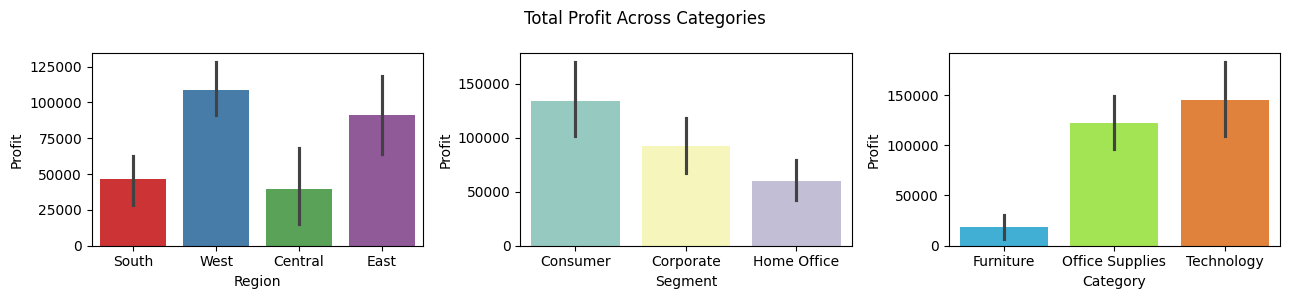

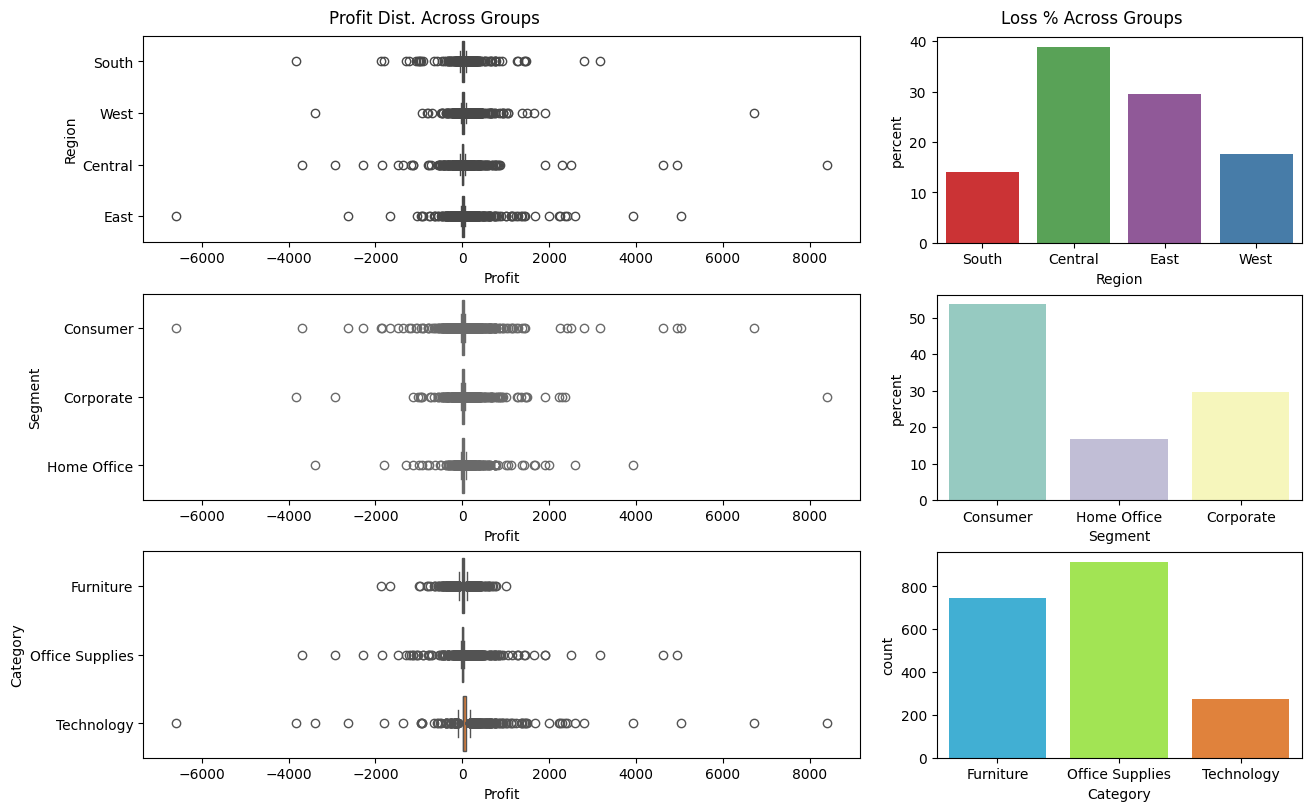

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3))
sns.barplot(x='Region', y='Profit', data=df, estimator='sum', ax=ax1,  hue='Region', palette='Set1')
sns.barplot(x='Segment', y='Profit', data=df, estimator='sum', ax=ax2, hue='Segment', palette='Set3')
sns.barplot(x='Category', y='Profit', data=df, estimator='sum', ax=ax3, hue='Category', palette='turbo')
fig.suptitle('Total Profit Across Categories')
plt.tight_layout()
plt.show()

fig = plt.figure(layout='constrained', figsize=(13, 8))
subfigs = fig.subfigures(1, 2, width_ratios=[2, 1])

axleft = subfigs[0].subplots(3, 1)
#fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 6))
sns.boxplot(x='Profit', y='Region', data=df, ax=axleft[0], hue='Region', palette='Set1')
sns.boxplot(x='Profit', y='Segment', data=df, hue='Segment', palette='Set3', ax=axleft[1])
sns.boxplot(x='Profit', y='Category', data=df, hue='Category', palette='turbo', ax=axleft[2])
subfigs[0].suptitle('Profit Dist. Across Groups')
#plt.tight_layout()

axright = subfigs[1].subplots(3, 1)
#fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 6))
sns.countplot(x='Region', data=df[df['Profit'] <= 0],  ax=axright[0], hue='Region', stat='percent', palette=dict(zip(['South', 'West', 'Central', 'East'], sns.color_palette('Set1', 4))))
sns.countplot(x='Segment', data=df[df['Profit'] <= 0], hue='Segment', stat='percent', palette=dict(zip(['Consumer', 'Corporate', 'Home Office'], sns.color_palette('Set3', 3))), ax=axright[1])
sns.countplot(x='Category', data=df[df['Profit'] <= 0], hue='Category', palette='turbo', ax=axright[2])
subfigs[1].suptitle('Loss % Across Groups')
#plt.tight_layout()
plt.show()

### Categorical Features

Category  Furniture  Office Supplies  Technology
Region                                          
Central         481             1422         420
East            600             1712         535
South           332              995         293
West            707             1897         599

chi2:3.674747602464948 pval:0.7205935913647219 dof:6 
expected:
[[ 492.82097468 1400.82037426  429.35865106]
 [ 603.98679075 1716.80396277  526.20924647]
 [ 343.6805764   976.89582708  299.42359652]
 [ 679.51165816 1931.47983589  592.00850595]]


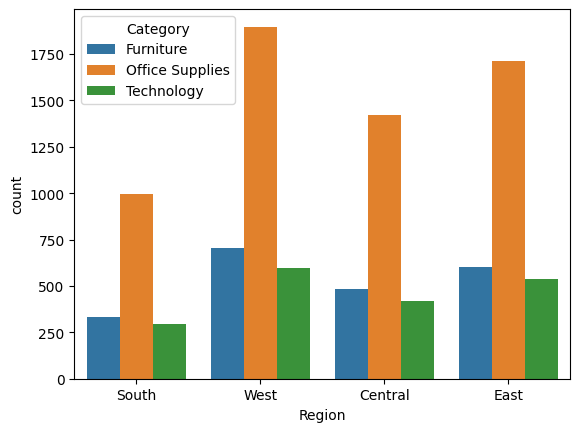

Segment  Consumer  Corporate  Home Office
Region                                   
Central      1212        673          438
East         1469        877          501
South         838        510          272
West         1672        960          571

chi2:5.020277872680612 pval:0.5412149696918234 dof:6 
expected:
[[1206.7139998   702.0374262   414.248574  ]
 [1478.91293906  860.39627739  507.69078355]
 [ 841.53107175  489.5827079   288.88622035]
 [1663.84198939  967.98358851  571.1744221 ]]


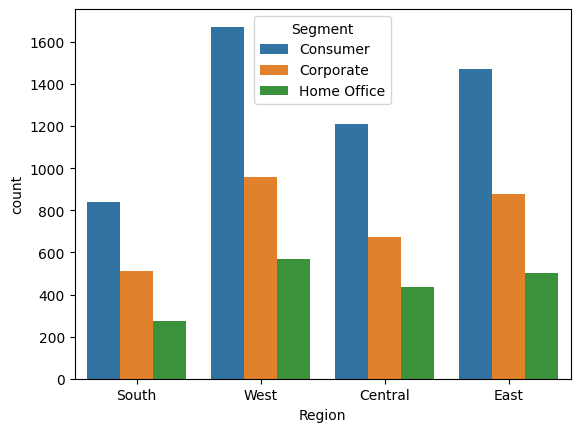

Segment          Consumer  Corporate  Home Office
Category                                         
Furniture            1113        646          361
Office Supplies      3127       1820         1079
Technology            951        554          342

chi2:1.5506518626410766 pval:0.8176328334819624 dof:4 
expected:
[[1101.26288402  640.68848194  378.04863404]
 [3130.28780146 1821.12678875 1074.58540979]
 [ 959.44931452  558.18472931  329.36595617]]


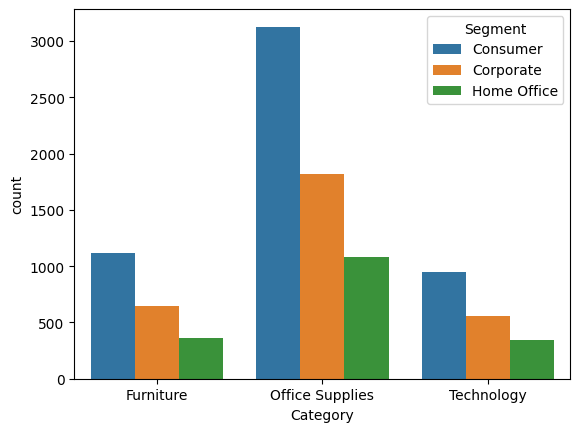

In [12]:
# Categorical
region_cat_freq = pd.crosstab(df['Region'], df['Category'])
print(region_cat_freq)
chi2, pval, dof, expected = stats.chi2_contingency(region_cat_freq)
print(f'\nchi2:{chi2} pval:{pval} dof:{dof} \nexpected:\n{expected}')
sns.countplot(x='Region', hue='Category', data=df)
plt.show()

region_seg_freq = pd.crosstab(df['Region'], df['Segment'])
print(region_seg_freq)
chi2, pval, dof, expected = stats.chi2_contingency(region_seg_freq)
print(f'\nchi2:{chi2} pval:{pval} dof:{dof} \nexpected:\n{expected}')
sns.countplot(x='Region', hue='Segment', data=df)
plt.show()

cat_seg_freq = pd.crosstab(df['Category'], df['Segment'])
print(cat_seg_freq)
chi2, pval, dof, expected = stats.chi2_contingency(cat_seg_freq)
print(f'\nchi2:{chi2} pval:{pval} dof:{dof} \nexpected:\n{expected}')
sns.countplot(x='Category', hue='Segment', data=df)
plt.show()

##

## Outliers and Anomalies
##### Outliers:
As observed earlier in this report, Sales has a natural heavy right skew which results in consistent outliers. There's also a large distance between Sales 95th quantile at \\$953. and Sales max value at \\$22638.48. So rather than focus only on specific outlier points, this section further analyses the highest 5% of our Sales (referred to as 'top sales' for the rest of this section).
- Sales Outliers Across Segments:
    Consumer Segment is responsible for almost half (49.3%) of top sales. Corporate segment accounts for 30.8%, and Home Office accounts for 19.9%.
- Sales Outliers Across Categories:
    Top 5 max Sales values are from Technology Category, and Technology also has the highest percentage of Sales from top sales at 47.5%. Furniture makes up 29%, and Office Supplies makes up 25.3%.
- Sales Outliers Across Regions:
    East region accounts for 31.3% of top sales, West region accounts for 30.0%, Central accounts for 20.4%, and South accounts for 18.3%.
- Sales Outliers Effect On Discount:
   As with the rest of the data, discount not associated with Sales within the top sales subset, but is assocaied even more with Profits.
- The top 5% of sales accounts for 44.47% of total sales and 52.89% of total profits. The top three outlier points are fron large technology sales.

##### Anomaly Of Note:
- While Technology has the highest percentage of outliers, Office Supplies which at first look has the lowest percentage of outliers, actually has the highest number of outliers for category subsets. Office Supplies subset has the highest skew at 11.83 compared to other Categories. This notable to ensure that outlier handling in future analysis does not overcorrect for other groups while missing Office Supplies.

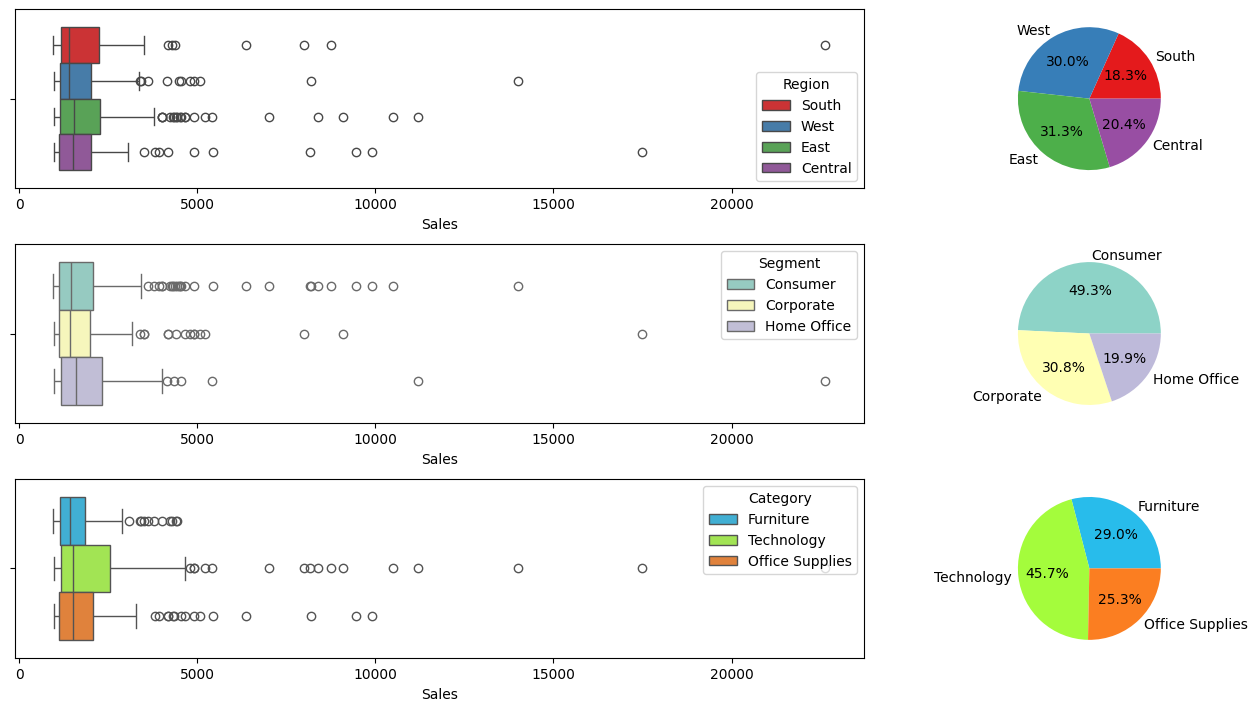

In [13]:
top_sales = df[df['Sales'] > sales_q95]

fig = plt.figure(layout='constrained', figsize=(13, 7))
subfigs = fig.subfigures(3, 1, height_ratios = [1, 1, 1])

axtop = subfigs[0].subplots(1, 2, width_ratios=[2, 1])
sns.boxplot(x='Sales', data=top_sales, hue='Region', palette='Set1', ax=axtop[0])
top_sales.groupby('Region')['Sales'].sum().reindex(index=['South', 'West', 'East', 'Central']).plot.pie(autopct='%.1f%%', colors=sns.color_palette('Set1'), ax=axtop[1])

axmid = subfigs[1].subplots(1, 2, width_ratios=[2, 1])
sns.boxplot(x='Sales', data=top_sales, hue='Segment', palette='Set3', ax=axmid[0])
top_sales.groupby('Segment')['Sales'].sum().plot.pie(autopct='%.1f%%', colors=sns.color_palette('Set3'), ax=axmid[1])

axbottom = subfigs[2].subplots(1, 2, width_ratios=[2, 1])
sns.boxplot(x='Sales', data=top_sales, hue='Category', palette='turbo', ax=axbottom[0])
top_sales.groupby('Category')['Sales'].sum().reindex(index=['Furniture', 'Technology', 'Office Supplies']).plot.pie(autopct='%.1f%%', colors=sns.color_palette('turbo', 3), ax=axbottom[1])

#plt.tight_layout()
plt.show()

In [14]:
print(df[df['Category'] == 'Office Supplies']['Sales'].skew())
print(df[df['Category'] == 'Technology']['Sales'].skew())
print(df[df['Category'] == 'Furniture']['Sales'].skew())

11.83536188537276
9.97316273090189
3.3482319586208185


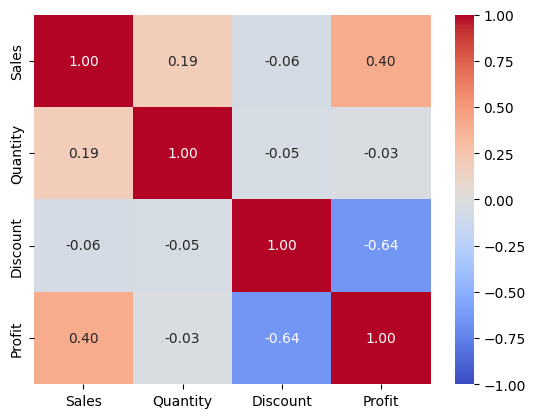

<Figure size 1300x300 with 0 Axes>

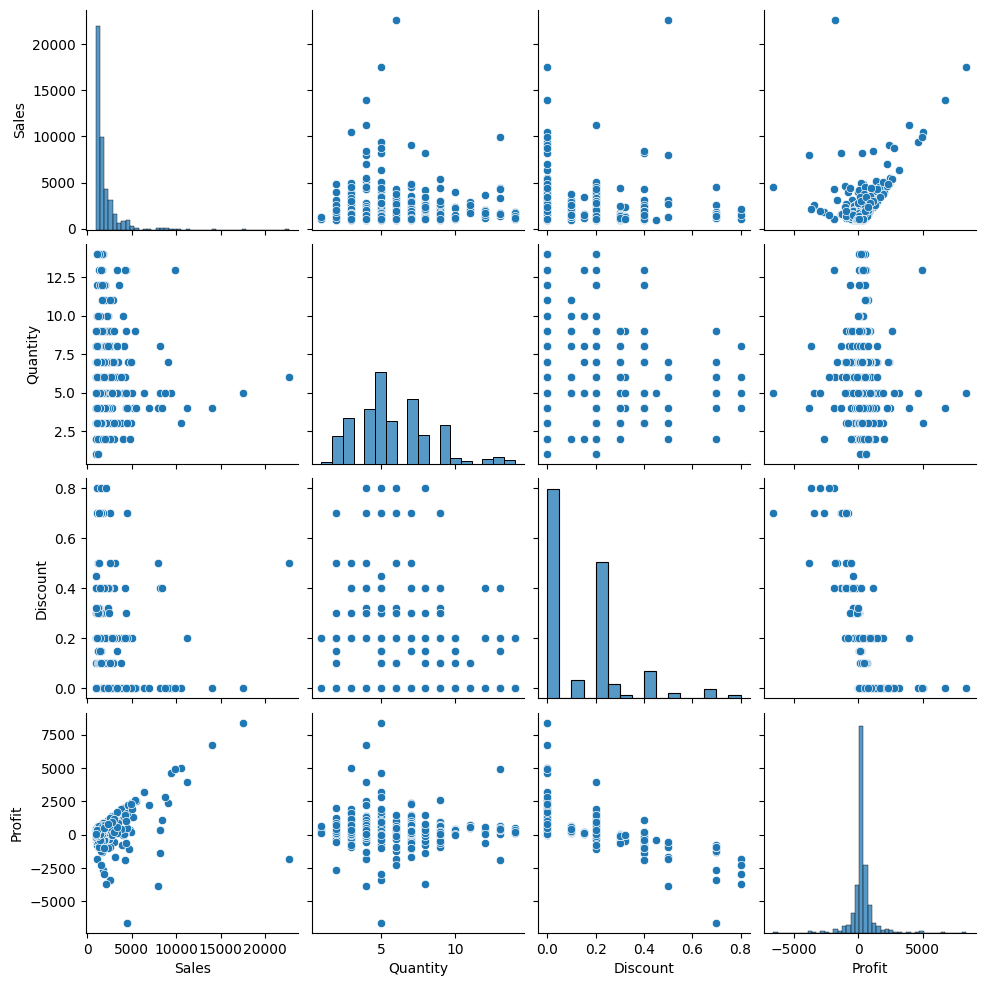

In [15]:
#topsales_corrdf = extreme_sales[df['Sales'] <= sales_q95]
topsales_corrdf = top_sales.drop(columns=['Postal Code'])
# topsales_corrdf.info()

# Correlation using spearman to account for skewness
topsales_corrmatrix = topsales_corrdf.corr(method='spearman', numeric_only=True)

sns.heatmap(topsales_corrmatrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.show()

plt.figure(figsize=(13, 3))
sns.pairplot(topsales_corrdf)

## Appendix (Additional observations)